# CCC coupling benchmarking for AgingMousebrain and HGSOC

This notebook evaluates how well different cell-cell communication representations align with curated gene programs and preserve biologically meaningful cell-cell relationships.

## Overview
The notebook performs four main tasks:
1. Select the dataset to analyze (`AgingMousebrain` or `HGSOC`).
2. Load SpiderNet outputs together with comparator results.
3. Run two benchmarks:
   - **Benchmark 1. Curated gene-coupling benchmark**  
     Test whether inferred communication features align with curated **receiver target genes** and **sender upstream regulators**.
   - **Benchmark 2. Within-cell-type similarity benchmark**  
     Test whether each method preserves expression-derived cell-cell similarity within the same cell type.


## 0. User controls

Set the dataset and run options here.

Supported datasets:
- `"AgingMousebrain"`
- `"HGSOC"`

Set `RECOMPUTE_NMFLR = True` to rerun NMF-LR even when a saved `Factor_LR_list.pkl` file is already available.


In [1]:
DATASET = "AgingMousebrain"   # options: "AgingMousebrain", "HGSOC"
RECOMPUTE_NMFLR = False
NMF_RANDOM_STATE = 0
NMF_MAX_ITER = 1000
MIN_CELLS_PER_CELLTYPE = 30


## 1. Imports and environment setup

In [2]:
import os
import sys
import json
import pickle
from collections import OrderedDict, defaultdict

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.decomposition import NMF
from scipy.stats import t
import matplotlib.patches as mpatches

import torch

# Add the SpiderNet package to the Python path
working_dir = "D:/SpiderNet/SpiderNet_proj/SpiderNet_proj/"
if working_dir not in sys.path:
    sys.path.append(working_dir)

from SpiderNet.utils import *  # provides helper functions such as scatter_nanmean

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


device: cuda


## 2. Dataset-specific configuration

Define all dataset-dependent paths and metadata fields

In [3]:
DATASET_CONFIG = {
    "AgingMousebrain": {
        "dataset_name": "AgingMousebrain",
        "display_name": "aging mouse brain",
        "version": "V1",
        "dim_envir": 30,
        "cellclass_name": "celltype",
        "data_path_main": "D:/SpiderNet/Data/AgingBrain/",
        "COMMOT_path_main": "D:/SpiderNet/Results/AgingBrain/COMMOT/",
        "ScCChain_path_main": "D:/SpiderNet/Results/AgingBrain/ScCChain/",
        "Spacia_path_main": None,
        "include_spacia": False,
        "targets_json_name": "targets_by_LR.json",
        "omnipath_regulatory_csv": "D:/SpiderNet/Data/Database/OmnipathR/interactions_regulatory_mouse.csv",
        "min_upstream_regulators": 1,
        "sample_obs_key": "age",
    },
    "HGSOC": {
        "dataset_name": "HGSOC",
        "display_name": "HGSC / HGSOC",
        "version": "V1",
        "dim_envir": 15,
        "cellclass_name": "cell.types",
        "data_path_main": "D:/SpiderNet/Data/HGSOC/",
        "COMMOT_path_main": "D:/SpiderNet/Results/HGSOC/COMMOT/",
        "ScCChain_path_main": "D:/SpiderNet/Results/HGSOC/ScCChain/",
        "Spacia_path_main": "D:/SpiderNet/Results/HGSOC/Spacia/",
        "include_spacia": True,
        "targets_json_name": "targets_by_LR.json",
        "omnipath_regulatory_csv": "D:/SpiderNet/Data/Database/OmnipathR/interactions_regulatory_human.csv",
        "min_upstream_regulators": 5,
        "sample_obs_key": "samples",
    },
}

if DATASET not in DATASET_CONFIG:
    raise ValueError(f"Unsupported DATASET: {DATASET}")

cfg = DATASET_CONFIG[DATASET].copy()
cfg


{'dataset_name': 'AgingMousebrain',
 'display_name': 'aging mouse brain',
 'version': 'V1',
 'dim_envir': 30,
 'cellclass_name': 'celltype',
 'data_path_main': 'D:/SpiderNet/Data/AgingBrain/',
 'COMMOT_path_main': 'D:/SpiderNet/Results/AgingBrain/COMMOT/',
 'ScCChain_path_main': 'D:/SpiderNet/Results/AgingBrain/ScCChain/',
 'Spacia_path_main': None,
 'include_spacia': False,
 'targets_json_name': 'targets_by_LR.json',
 'omnipath_regulatory_csv': 'D:/SpiderNet/Data/Database/OmnipathR/interactions_regulatory_mouse.csv',
 'min_upstream_regulators': 1,
 'sample_obs_key': 'age'}

In [4]:
# Define SpiderNet result, processed-data, and benchmark output paths
save_path_main = cfg["data_path_main"].replace("Data/", "Results/")
save_path_main_cur = os.path.join(save_path_main, cfg["version"])
os.makedirs(save_path_main_cur, exist_ok=True)

result_tag = f"SpiderNet_Result_dim{cfg['dim_envir']}"

file_savepath_main = os.path.join(save_path_main_cur, result_tag)
if not file_savepath_main.endswith(os.sep):
    file_savepath_main += os.sep
file_savepath_main = file_savepath_main.replace("\\", "/")

processed_data_dir_cfg = cfg.get("processed_data_dir", None)
processed_data_candidates = []

if processed_data_dir_cfg is not None and str(processed_data_dir_cfg).strip() != "":
    processed_data_candidates.append(str(processed_data_dir_cfg))
processed_data_candidates.extend([
    os.path.join(save_path_main, "ProcessedData"),
    os.path.join(save_path_main_cur, "ProcessedData"),
])

processed_data_dir = None
for candidate in processed_data_candidates:
    candidate_norm = candidate.replace("\\", "/")
    if os.path.exists(candidate_norm):
        processed_data_dir = candidate_norm
        break

if processed_data_dir is None:
    processed_data_dir = processed_data_candidates[0].replace("\\", "/")

benchmark_outdir = os.path.join(file_savepath_main, "Unified_CCC_benchmarking").replace("\\", "/")
os.makedirs(benchmark_outdir, exist_ok=True)

print("SpiderNet result directory:", file_savepath_main)
print("Processed data directory:", processed_data_dir)
print("Benchmark output directory:", benchmark_outdir)


SpiderNet result directory: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/
Processed data directory: D:/SpiderNet/Results/AgingBrain/ProcessedData
Benchmark output directory: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking


## 3. Load SpiderNet outputs

Read the precomputed SpiderNet objects needed for benchmarking, including AnnData objects, graph data, and edge-level meta-interaction features.

In [5]:
from SpiderNet.io import get_spidernet_pyg_list_path, load_spidernet_pyg_list, spidernet_pyg_list_exists
required_processed_files = [
    "adata_list.pkl",
    "LR_list.pkl",
]

required_result_files = [
    "Factor_envir_list.pkl",
]

missing_processed = [
    file_name for file_name in required_processed_files
    if not os.path.exists(os.path.join(processed_data_dir, file_name))
]
missing_result = [
    file_name for file_name in required_result_files
    if not os.path.exists(os.path.join(file_savepath_main, file_name))
]

if missing_processed or not spidernet_pyg_list_exists(processed_data_dir):
    raise FileNotFoundError(
        "ProcessedData is incomplete. Missing files under "
        f"{processed_data_dir}: {missing_processed}\n"
        "If your ProcessedData folder is stored outside the version directory, "
        "set cfg['processed_data_dir'] explicitly or place it at the dataset-level "
        "Results folder."
    )

if missing_result:
    raise FileNotFoundError(
        "SpiderNet result directory is incomplete. Missing files under "
        f"{file_savepath_main}: {missing_result}"
    )

adata_list_path = os.path.join(processed_data_dir, "adata_list.pkl")
SpiderNet_data_pyg_list_path = str(get_spidernet_pyg_list_path(processed_data_dir))
LR_list_path = os.path.join(processed_data_dir, "LR_list.pkl")

Factor_envir_list_path = os.path.join(file_savepath_main, "Factor_envir_list.pkl")
Factor_LR_list_path = os.path.join(file_savepath_main, "Factor_LR_list.pkl")

adata_all_path = os.path.join(processed_data_dir, "adata_all.h5ad")

adata_list = pd.read_pickle(adata_list_path)
SpiderNet_data_pyg_list = load_spidernet_pyg_list(SpiderNet_data_pyg_list_path)
Factor_envir_list = pd.read_pickle(Factor_envir_list_path)

if os.path.exists(adata_all_path):
    adata_all = sc.read_h5ad(adata_all_path)
else:
    if len(adata_list) == 0:
        raise ValueError(f"No slices found in {adata_list_path}")
    if len(adata_list) == 1:
        adata_all = adata_list[0].copy()
    else:
        adata_all = sc.concat(adata_list, join="inner", merge="same")

print("n_slices:", len(adata_list))
print("adata_all:", adata_all.shape)
print("cell class column:", cfg["cellclass_name"])
print("Processed adata_list path:", adata_list_path)
print("Processed SpiderNet graph path:", SpiderNet_data_pyg_list_path)
print("SpiderNet factor path:", Factor_envir_list_path)
print("NMF-LR factor cache path:", Factor_LR_list_path)


n_slices: 10
adata_all: (712695, 300)
cell class column: celltype
Processed adata_list path: D:/SpiderNet/Results/AgingBrain/ProcessedData\adata_list.pkl
Processed SpiderNet graph path: D:/SpiderNet/Results/AgingBrain/ProcessedData\SpiderNet_data_pyg_list.pkl
SpiderNet factor path: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Factor_envir_list.pkl
NMF-LR factor cache path: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Factor_LR_list.pkl


### NMF-LR

In [6]:
def build_nmflr_factors(SpiderNet_data_pyg_list, n_components, random_state=0, max_iter=1000):
    Factor_LR_list = []
    for slice_index in range(len(SpiderNet_data_pyg_list)):
        print(f"Running NMF-LR for slice {slice_index + 1}/{len(SpiderNet_data_pyg_list)}")
        cellpair_LRpair_neigh_cur = SpiderNet_data_pyg_list[slice_index]["cellpair_LRpair_neigh"]

        nmf_LR = NMF(
            n_components=n_components,
            init="nndsvda",
            random_state=random_state,
            max_iter=max_iter,
        )
        factor_nmf_LR = nmf_LR.fit_transform(cellpair_LRpair_neigh_cur)

        factor_nmf_LR_colmax = np.max(factor_nmf_LR, axis=0)
        factor_nmf_LR_colmax[factor_nmf_LR_colmax == 0] = 1.0
        factor_nmf_LR = factor_nmf_LR / factor_nmf_LR_colmax

        Factor_LR_list.append(factor_nmf_LR.astype(np.float32, copy=False))
    return Factor_LR_list


if (not RECOMPUTE_NMFLR) and os.path.exists(Factor_LR_list_path):
    Factor_LR_list = pd.read_pickle(Factor_LR_list_path)
    print("Loaded existing NMF-LR factors:", Factor_LR_list_path)
else:
    Factor_LR_list = build_nmflr_factors(
        SpiderNet_data_pyg_list,
        n_components=cfg["dim_envir"],
        random_state=NMF_RANDOM_STATE,
        max_iter=NMF_MAX_ITER,
    )
    with open(Factor_LR_list_path, "wb") as f:
        pickle.dump(Factor_LR_list, f)
    print("Saved NMF-LR factors:", Factor_LR_list_path)


Loaded existing NMF-LR factors: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Factor_LR_list.pkl


## 4. Shared helper functions

Define plotting utilities, aggregation functions, and summary helpers used across both benchmarks.

In [7]:
def set_plot_style():
    plt.close("all")
    plt.style.use("default")
    rcParams.update({
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "Arial",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    })


METHOD_COLORS = {
    "SpiderNet": {"edge": "#9F3B38", "fill": "#E1B6A7"},
    "NMF-LR": {"edge": "#82CCE2", "fill": "#D4ECF1"},
    "COMMOT": {"edge": "#519384", "fill": "#B9CEC7"},
    "ScCChain": {"edge": "#636491", "fill": "#A6A2B9"},
    "Spacia": {"edge": "#FED881", "fill": "#FFF2D2"},
}


def join_plus(x):
    return "+".join(str(i) for i in x if i is not None and str(i) != "nan")


def to_dense_2d(X):
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)


def aggregate_edge_features(edge_features, edge_index_col, num_cells, device):
    agg = scatter_nanmean(
        torch.as_tensor(edge_features, dtype=torch.float32, device=device),
        edge_index_col.to(torch.int64).to(device),
        dim=0,
        dim_size=num_cells,
    ).to("cpu").numpy()
    return agg


def aggregate_sender_receiver(edge_features, edge_index, num_cells, device):
    sender_agg = aggregate_edge_features(edge_features, edge_index[:, 0], num_cells, device)
    receiver_agg = aggregate_edge_features(edge_features, edge_index[:, 1], num_cells, device)
    return {
        "sender": sender_agg,
        "receiver": receiver_agg,
        "combined": np.hstack([sender_agg, receiver_agg]),
    }


def edge_matrix_from_square(square_mat, rows, cols):
    if sp.issparse(square_mat):
        square_mat = square_mat.tocsr()
        return square_mat[rows, cols].A1.astype(np.float32, copy=False)
    return square_mat[rows, cols].astype(np.float32, copy=False)


def summarize_values(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "sd": np.nan}
    if x.size == 1:
        return {"n": 1, "mean": float(np.mean(x)), "median": float(np.median(x)), "sd": np.nan}
    return {
        "n": int(x.size),
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "sd": float(np.std(x, ddof=1)),
    }


def one_sided_mw_greater(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if (x.size == 0) or (y.size == 0):
        return np.nan
    return mannwhitneyu(x, y, alternative="greater").pvalue


## 5. Load comparator outputs

Load the communication features produced by the comparator methods and align them to the same edge structure used by SpiderNet.

In [8]:
def get_commot_file_for_slice(adata_sub, cfg):
    if cfg["dataset_name"] == "HGSOC":
        sample_cur = np.unique(adata_sub.obs[cfg["sample_obs_key"]])[0]
        return os.path.join(cfg["COMMOT_path_main"], f"{sample_cur}_COMMOT_cellchat.h5ad")
    elif cfg["dataset_name"] == "AgingMousebrain":
        age_cur = np.unique(adata_sub.obs[cfg["sample_obs_key"]])[0]
        return os.path.join(cfg["COMMOT_path_main"], f"aging_coronal_age{age_cur}_commot.h5ad")
    else:
        raise ValueError(f"Unsupported dataset: {cfg['dataset_name']}")


def load_commot_outputs(adata_list, SpiderNet_data_pyg_list, cfg):
    COMMOT_score_list = []

    for slice_index, adata_sub in enumerate(adata_list):
        print(f"Loading COMMOT for slice {slice_index + 1}/{len(adata_list)}")
        commot_path = get_commot_file_for_slice(adata_sub, cfg)
        COMMOT_adata = sc.read_h5ad(commot_path)

        edge_index_cur = SpiderNet_data_pyg_list[slice_index]["edge_index"]
        edge_np = edge_index_cur.detach().cpu().numpy()
        rows = edge_np[:, 0].astype(np.int64, copy=False)
        cols = edge_np[:, 1].astype(np.int64, copy=False)
        E = rows.shape[0]

        keys = list(COMMOT_adata.obsp.keys())
        total_key = "commot-cellchat-total-total"
        pathway_keys = [
            k for k in keys
            if k.startswith("commot-cellchat-") and len(k.split("-")) == 3 and k != total_key
        ]

        # Load pathway-level COMMOT scores for each edge
        pathway_array = np.zeros((E, len(pathway_keys)), dtype=np.float32)
        for j, key in enumerate(pathway_keys):
            pathway_array[:, j] = edge_matrix_from_square(COMMOT_adata.obsp[key], rows, cols)
        COMMOT_score_list.append(pathway_array)

    return COMMOT_score_list


def load_sccchain_outputs(adata_list, SpiderNet_data_pyg_list, cfg):
    txt_path = os.path.join(cfg["ScCChain_path_main"], "h5ad_files.txt")
    adata_list_ScCChain = pd.read_csv(txt_path, header=None)[0].tolist()

    n_obs_ref = [adata_sub.n_obs for adata_sub in adata_list]
    n_obs_scc = []
    for p in adata_list_ScCChain:
        ad = sc.read_h5ad(p)
        n_obs_scc.append(ad.n_obs)

    index_map = []
    for n in n_obs_ref:
        matched = np.where(np.array(n_obs_scc) == n)[0]
        if len(matched) == 0:
            raise ValueError(f"Cannot match ScCChain result by n_obs={n}")
        index_map.append(matched[0])

    ScCChain_CPscore_list = []
    for slice_index in range(len(adata_list)):
        print(f"Loading ScCChain for slice {slice_index + 1}/{len(adata_list)}")
        matched_idx = index_map[slice_index]

        src_path = adata_list_ScCChain[matched_idx]
        stem = os.path.splitext(os.path.basename(src_path))[0]
        score_path = os.path.join(cfg["ScCChain_path_main"], f"{stem}_ScCChain_edge_program_scores.csv")
        score_df = pd.read_csv(score_path, index_col=None)

        edge_index_cur = SpiderNet_data_pyg_list[slice_index]["edge_index"]
        edge_np = edge_index_cur.detach().cpu().numpy()
        rows = edge_np[:, 0].astype(np.int64, copy=False)
        cols = edge_np[:, 1].astype(np.int64, copy=False)
        E = rows.shape[0]

        key_use = score_df.columns.tolist()[2:]
        cellpair_CPscore_array = np.zeros((E, len(key_use)), dtype=np.float32)

        for j, cp_key in enumerate(key_use):
            sub_df = score_df[["sender_index", "receiver_index", cp_key]].copy()
            sender_index_cur = sub_df["sender_index"].values.astype(np.int64) - 1
            receiver_index_cur = sub_df["receiver_index"].values.astype(np.int64) - 1

            A = np.zeros((adata_list[slice_index].n_obs, adata_list[slice_index].n_obs), dtype=np.float32)
            A[sender_index_cur, receiver_index_cur] = sub_df[cp_key].values.astype(np.float32)
            cellpair_CPscore_array[:, j] = edge_matrix_from_square(A, rows, cols)

        ScCChain_CPscore_list.append(cellpair_CPscore_array)

    return ScCChain_CPscore_list


def load_spacia_outputs(adata_list, SpiderNet_data_pyg_list, cfg):
    if not cfg["include_spacia"]:
        return None

    spacia_dir = os.path.join(cfg["Spacia_path_main"], "spacia_outputs")
    adata_list_Spacia = sorted([f for f in os.listdir(spacia_dir) if f.endswith(".h5ad")])

    n_obs_ref = [adata_sub.n_obs for adata_sub in adata_list]
    n_obs_spacia = []
    for fname in adata_list_Spacia:
        ad = sc.read_h5ad(os.path.join(spacia_dir, fname), backed="r")
        n_obs_spacia.append(ad.n_obs)
        del ad

    index_map = []
    for n in n_obs_ref:
        matched = np.where(np.array(n_obs_spacia) == n)[0]
        if len(matched) == 0:
            raise ValueError(f"Cannot match Spacia result by n_obs={n}")
        index_map.append(matched[0])

    Spacia_CP_list = []
    for slice_index in range(len(adata_list)):
        print(f"Loading Spacia for slice {slice_index + 1}/{len(adata_list)}")
        fname = adata_list_Spacia[index_map[slice_index]]
        spacia_path = os.path.join(spacia_dir, fname)
        Spacia_adata = sc.read_h5ad(spacia_path)

        edge_index_cur = SpiderNet_data_pyg_list[slice_index]["edge_index"]
        edge_np = edge_index_cur.detach().cpu().numpy()
        rows = edge_np[:, 0].astype(np.int64, copy=False)
        cols = edge_np[:, 1].astype(np.int64, copy=False)
        E = rows.shape[0]

        n_programs = Spacia_adata.obsp["interaction_scores"].shape[2]
        cellpair_CP_array = np.zeros((E, n_programs), dtype=np.float32)

        for j in range(n_programs):
            A = Spacia_adata.obsp["interaction_scores"][:, :, j]
            cellpair_CP_array[:, j] = edge_matrix_from_square(A, rows, cols)

        Spacia_CP_list.append(cellpair_CP_array)

    return Spacia_CP_list


In [9]:
COMMOT_score_list = load_commot_outputs(
    adata_list,
    SpiderNet_data_pyg_list,
    cfg,
)

ScCChain_CPscore_list = load_sccchain_outputs(
    adata_list,
    SpiderNet_data_pyg_list,
    cfg,
)

Spacia_CP_list = load_spacia_outputs(
    adata_list,
    SpiderNet_data_pyg_list,
    cfg,
)

print("COMMOT slices:", len(COMMOT_score_list))
print("ScCChain slices:", len(ScCChain_CPscore_list))
print("Spacia enabled:", cfg["include_spacia"])


Loading COMMOT for slice 1/10
Loading COMMOT for slice 2/10
Loading COMMOT for slice 3/10
Loading COMMOT for slice 4/10
Loading COMMOT for slice 5/10
Loading COMMOT for slice 6/10
Loading COMMOT for slice 7/10
Loading COMMOT for slice 8/10
Loading COMMOT for slice 9/10
Loading COMMOT for slice 10/10
Loading ScCChain for slice 1/10
Loading ScCChain for slice 2/10
Loading ScCChain for slice 3/10
Loading ScCChain for slice 4/10
Loading ScCChain for slice 5/10
Loading ScCChain for slice 6/10
Loading ScCChain for slice 7/10
Loading ScCChain for slice 8/10
Loading ScCChain for slice 9/10
Loading ScCChain for slice 10/10
COMMOT slices: 10
ScCChain slices: 10
Spacia enabled: False


# Benchmark 1. Curated gene-coupling benchmark

This benchmark asks whether inferred communication features recover curated biology linked to ligand-receptor pairs.

For each slice:
1. Build a **cell × LR-set** matrix from curated **receiver target genes** and **sender upstream regulators**.
2. Aggregate each method's edge-level outputs to the **receiver side** for target analysis and the **sender side** for regulator analysis.
3. For each representative LR set, compute the **maximum Spearman correlation** between curated gene activity and inferred communication features.
4. Summarize the distribution of correlations across LR sets and slices.

Higher correlation indicates that a method more strongly captures curated downstream targets or upstream regulators associated with the communication axis.


In [10]:
# Load ligand-receptor pairs and curated target-gene annotations
gene_names = adata_all.var_names.tolist()
LR_list = pd.read_pickle(os.path.join(processed_data_dir, "LR_list.pkl"))

LR_merge = [f"{join_plus(LR_sub[0])}->{join_plus(LR_sub[1])}" for LR_sub in LR_list]

with open(os.path.join(benchmark_outdir, "gene_names.txt"), "w") as f:
    for gene in gene_names:
        f.write(f"{gene}\n")

with open(os.path.join(benchmark_outdir, "LR_pairs.txt"), "w") as f:
    for lr in LR_merge:
        f.write(f"{lr}\n")

with open(os.path.join(file_savepath_main, cfg["targets_json_name"]), "r") as f:
    targets_by_LR = json.load(f)

print("n_genes:", len(gene_names))
print("n_LR_pairs:", len(LR_list))
print("n_target_annotated_pairs:", len(targets_by_LR))


n_genes: 300
n_LR_pairs: 85
n_target_annotated_pairs: 85


In [11]:
def dedup_gene_sets(gene_sets_by_lr):
    gene_sets_by_setid = OrderedDict()
    repkey_by_setid = {}
    setid_by_lr = {}
    lrs_by_setid = defaultdict(list)

    canon_to_setid = {}
    set_counter = 0

    for lr, genes in gene_sets_by_lr.items():
        genes_can = sorted({g for g in genes if g is not None and g != ""})
        canon = ";".join(genes_can)

        if canon not in canon_to_setid:
            set_counter += 1
            set_id = f"set{set_counter:06d}"
            canon_to_setid[canon] = set_id
            gene_sets_by_setid[set_id] = genes_can
            repkey_by_setid[set_id] = lr

        set_id = canon_to_setid[canon]
        setid_by_lr[lr] = set_id
        lrs_by_setid[set_id].append(lr)

    return gene_sets_by_setid, repkey_by_setid, setid_by_lr, dict(lrs_by_setid)


targets_by_setid, repkey_targets, setid_by_lr_targets, lrs_by_setid_targets = dedup_gene_sets(targets_by_LR)
targets_by_LR_unique = {
    repkey_targets[set_id]: genes
    for set_id, genes in targets_by_setid.items()
}

print("target-annotated LR keys before deduplication:", len(targets_by_LR))
print("unique target sets:", len(targets_by_LR_unique))


target-annotated LR keys before deduplication: 85
unique target sets: 23


In [12]:
# Load curated upstream regulator annotations from OmniPath
interactions_regulatory = pd.read_csv(cfg["omnipath_regulatory_csv"])
interactions_regulatory_stimulation = interactions_regulatory[
    interactions_regulatory["is_stimulation"] & (~interactions_regulatory["is_inhibition"])
]

upstream_regulators_dict = {}
for LR in LR_list:
    ligand = LR[0]
    LR_key = f"{join_plus(LR[0])}->{join_plus(LR[1])}"

    if ligand in interactions_regulatory_stimulation["target_genesymbol"].values:
        regulators = interactions_regulatory_stimulation[
            np.isin(interactions_regulatory_stimulation["target_genesymbol"], ligand)
        ]["source_genesymbol"].tolist()
        regulators = np.unique(regulators).tolist()
        regulators = [r for r in regulators if r in gene_names]

        if len(regulators) >= cfg["min_upstream_regulators"]:
            upstream_regulators_dict[LR_key] = regulators

regulators_by_setid, repkey_regulators, setid_by_lr_regulators, lrs_by_setid_regulators = dedup_gene_sets(
    upstream_regulators_dict
)
regulators_by_LR_unique = {
    repkey_regulators[set_id]: genes
    for set_id, genes in regulators_by_setid.items()
}

print("annotated regulator LR keys:", len(upstream_regulators_dict))
print("unique regulator sets:", len(regulators_by_LR_unique))


annotated regulator LR keys: 30
unique regulator sets: 12


C:\Users\junji\AppData\Local\Temp\ipykernel_43696\3942672919.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  interactions_regulatory = pd.read_csv(cfg["omnipath_regulatory_csv"])


In [13]:
def cell_by_pair_mean_genesets(
    adata_sub,
    genesets_by_LR_unique,
    use_layer=None,
    dtype=np.float32,
    fill_value=np.nan,
    return_dataframe=True,
):
    X = adata_sub.X if use_layer is None else adata_sub.layers[use_layer]
    if not sp.issparse(X):
        X = np.asarray(X)

    var_names = np.asarray(adata_sub.var_names)
    gene_to_idx = {g: i for i, g in enumerate(var_names)}

    pair_names = list(genesets_by_LR_unique.keys())
    n_pairs = len(pair_names)

    rows, cols, data = [], [], []
    n_found = np.zeros(n_pairs, dtype=np.int32)

    for j, lr in enumerate(pair_names):
        genes = genesets_by_LR_unique[lr]
        idx = [gene_to_idx[g] for g in genes if g in gene_to_idx]
        if len(idx) == 0:
            continue
        idx = np.unique(idx)
        n_found[j] = len(idx)
        w = 1.0 / float(len(idx))
        rows.extend(idx.tolist())
        cols.extend([j] * len(idx))
        data.extend([w] * len(idx))

    W = sp.csr_matrix((data, (rows, cols)), shape=(adata_sub.n_vars, n_pairs), dtype=dtype)

    if sp.issparse(X):
        scores = (X @ W).toarray().astype(dtype, copy=False)
    else:
        scores = (X @ W.toarray()).astype(dtype, copy=False)

    zero_mask = n_found == 0
    if np.any(zero_mask):
        scores[:, zero_mask] = fill_value

    if return_dataframe:
        scores = pd.DataFrame(scores, index=adata_sub.obs_names, columns=pair_names)

    return scores, pair_names, n_found


def compute_rowmax_spearman_df(X_df, Y_array, slice_index, prefix="Slice_"):
    X = np.asarray(X_df, dtype=float)
    Y = np.asarray(Y_array, dtype=float)

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError(f"X and Y must both be 2D, got X.shape={X.shape}, Y.shape={Y.shape}")
    if X.shape[0] != Y.shape[0]:
        raise ValueError(f"X and Y must have the same n_cells, got {X.shape} vs {Y.shape}")

    if X.shape[1] == 0:
        return pd.DataFrame(index=[f"{prefix}{slice_index + 1}"])
    if Y.shape[1] == 0:
        return pd.DataFrame(np.nan, index=[f"{prefix}{slice_index + 1}"], columns=X_df.columns)

    X = np.nan_to_num(X, nan=0.0)
    Y = np.nan_to_num(Y, nan=0.0)

    corr_all, _ = spearmanr(X, Y, axis=0)
    corr_xy = corr_all[:X.shape[1], X.shape[1]:]
    rowmax = np.nanmax(corr_xy, axis=1)

    return pd.DataFrame(
        [rowmax],
        index=[f"{prefix}{slice_index + 1}"],
        columns=X_df.columns,
    )


In [14]:
# Run Benchmark 1 for all slices and methods
target_corr = {method: [] for method in ["SpiderNet", "NMF-LR", "COMMOT", "ScCChain"]}
regulator_corr = {method: [] for method in ["SpiderNet", "NMF-LR", "COMMOT", "ScCChain"]}

if cfg["include_spacia"]:
    target_corr["Spacia"] = []
    regulator_corr["Spacia"] = []

for slice_index in range(len(adata_list)):
    print(f"Benchmark 1 | slice {slice_index + 1}/{len(adata_list)}")
    adata_sub = adata_list[slice_index]
    edge_index_sub = SpiderNet_data_pyg_list[slice_index]["edge_index"]
    num_cell_sub = SpiderNet_data_pyg_list[slice_index].x.shape[0]

    target_df, _, _ = cell_by_pair_mean_genesets(
        adata_sub,
        targets_by_LR_unique,
        use_layer=None,
        fill_value=np.nan,
    )
    regulator_df, _, _ = cell_by_pair_mean_genesets(
        adata_sub,
        regulators_by_LR_unique,
        use_layer=None,
        fill_value=np.nan,
    )

    method_edge_features = {
        "SpiderNet": np.asarray(Factor_envir_list[slice_index], dtype=float),
        "NMF-LR": np.asarray(Factor_LR_list[slice_index], dtype=float),
        "COMMOT": np.asarray(COMMOT_score_list[slice_index], dtype=float),
        "ScCChain": np.asarray(ScCChain_CPscore_list[slice_index], dtype=float),
    }
    if cfg["include_spacia"]:
        method_edge_features["Spacia"] = np.asarray(Spacia_CP_list[slice_index], dtype=float)

    for method_name, edge_features in method_edge_features.items():
        agg = aggregate_sender_receiver(edge_features, edge_index_sub, num_cell_sub, device)

        target_corr[method_name].append(
            compute_rowmax_spearman_df(target_df, agg["receiver"], slice_index)
        )
        regulator_corr[method_name].append(
            compute_rowmax_spearman_df(regulator_df, agg["sender"], slice_index)
        )

target_corr_frames = {k: pd.concat(v, axis=0) for k, v in target_corr.items()}
regulator_corr_frames = {k: pd.concat(v, axis=0) for k, v in regulator_corr.items()}

for name, df in target_corr_frames.items():
    df.to_csv(os.path.join(benchmark_outdir, f"Benchmark1_target_corr_{name.replace('/', '_')}.csv"))
for name, df in regulator_corr_frames.items():
    df.to_csv(os.path.join(benchmark_outdir, f"Benchmark1_regulator_corr_{name.replace('/', '_')}.csv"))

print("Benchmark 1 finished.")


Benchmark 1 | slice 1/10


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\junji\AppData\Local\Temp\ipykernel_43696\467182653.py:70: RuntimeWarning: All-NaN slice encountered
  rowmax = np.nanmax(corr_xy, axis=1)


Benchmark 1 | slice 2/10
Benchmark 1 | slice 3/10
Benchmark 1 | slice 4/10
Benchmark 1 | slice 5/10
Benchmark 1 | slice 6/10
Benchmark 1 | slice 7/10
Benchmark 1 | slice 8/10
Benchmark 1 | slice 9/10
Benchmark 1 | slice 10/10
Benchmark 1 finished.


In [15]:
def corr_frames_to_long(frame_dict, feature_type):
    recs = []
    for method_name, df in frame_dict.items():
        tmp = df.copy()
        tmp["Slice"] = tmp.index.astype(str)
        tmp = tmp.melt(id_vars=["Slice"], var_name="RepresentativeLR", value_name="Correlation")
        tmp["Method"] = method_name
        tmp["FeatureType"] = feature_type
        recs.append(tmp)

    out = pd.concat(recs, axis=0, ignore_index=True)
    out["Correlation"] = pd.to_numeric(out["Correlation"], errors="coerce")
    return out


def mean_ci95(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size

    if n == 0:
        return np.nan, np.nan, np.nan, 0

    m = float(np.mean(x))
    if n == 1:
        return m, m, m, 1

    sem = np.std(x, ddof=1) / np.sqrt(n)
    t_crit = t.ppf(0.975, df=n - 1)
    half_width = t_crit * sem
    return m, float(m - half_width), float(m + half_width), int(n)


def make_benchmark1_tables(target_corr_frames, regulator_corr_frames):
    long_df = pd.concat(
        [
            corr_frames_to_long(target_corr_frames, "Receiver targets"),
            corr_frames_to_long(regulator_corr_frames, "Sender regulators"),
        ],
        axis=0,
        ignore_index=True,
    )

    method_order = [
        m for m in ["SpiderNet", "NMF-LR", "COMMOT", "ScCChain", "Spacia"]
        if m in long_df["Method"].unique()
    ]

    plot_summary_records = []
    stats_records = []

    for feature_type in ["Receiver targets", "Sender regulators"]:
        sub_ft = long_df[long_df["FeatureType"] == feature_type].copy()

        rep_lr_order = (
            sub_ft[sub_ft["Method"] == "SpiderNet"]
            .groupby("RepresentativeLR")["Correlation"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

        for rep_lr in rep_lr_order:
            spider_vals = sub_ft[
                (sub_ft["RepresentativeLR"] == rep_lr) &
                (sub_ft["Method"] == "SpiderNet")
            ]["Correlation"].dropna().to_numpy()

            for method in method_order:
                vals = sub_ft[
                    (sub_ft["RepresentativeLR"] == rep_lr) &
                    (sub_ft["Method"] == method)
                ]["Correlation"].dropna().to_numpy()

                mean_v, ci_low, ci_high, n = mean_ci95(vals)
                median_v = float(np.median(vals)) if vals.size > 0 else np.nan

                plot_summary_records.append({
                    "FeatureType": feature_type,
                    "RepresentativeLR": rep_lr,
                    "Method": method,
                    "mean": mean_v,
                    "ci95_low": ci_low,
                    "ci95_high": ci_high,
                    "median": median_v,
                    "n": n,
                })

                if method != "SpiderNet":
                    stats_records.append({
                        "FeatureType": feature_type,
                        "RepresentativeLR": rep_lr,
                        "Comparison": f"SpiderNet > {method}",
                        "Method": method,
                        "p_one_sided_mw": one_sided_mw_greater(spider_vals, vals),
                        "n_SpiderNet": int(spider_vals.size),
                        "n_other": int(vals.size),
                        "median_SpiderNet": float(np.median(spider_vals)) if spider_vals.size > 0 else np.nan,
                        "median_other": median_v,
                    })

    plot_summary_df = pd.DataFrame(plot_summary_records)
    stats_df = pd.DataFrame(stats_records)

    return long_df, plot_summary_df, stats_df, method_order


benchmark1_long_df, benchmark1_plot_summary_df, benchmark1_stats_df, benchmark1_method_order = make_benchmark1_tables(
    target_corr_frames,
    regulator_corr_frames,
)

benchmark1_long_df.to_csv(os.path.join(benchmark_outdir, "Benchmark1_long.csv"), index=False)
benchmark1_plot_summary_df.to_csv(os.path.join(benchmark_outdir, "Benchmark1_plot_summary.csv"), index=False)
benchmark1_stats_df.to_csv(os.path.join(benchmark_outdir, "Benchmark1_pairwise_stats.csv"), index=False)

print("Saved Benchmark 1 tables:")
print(" -", os.path.join(benchmark_outdir, "Benchmark1_long.csv"))
print(" -", os.path.join(benchmark_outdir, "Benchmark1_plot_summary.csv"))
print(" -", os.path.join(benchmark_outdir, "Benchmark1_pairwise_stats.csv"))

print("\nBenchmark 1 plot summary (first 12 rows):")
display(benchmark1_plot_summary_df.head(12))

print("\nBenchmark 1 pairwise statistics (first 12 rows):")
display(benchmark1_stats_df.head(12))

Saved Benchmark 1 tables:
 - D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark1_long.csv
 - D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark1_plot_summary.csv
 - D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark1_pairwise_stats.csv

Benchmark 1 plot summary (first 12 rows):


,FeatureType,RepresentativeLR,Method,mean,ci95_low,ci95_high,median,n
0,Receiver targets,Cldn11->Cldn11,SpiderNet,0.445706,0.427340,0.464073,0.454082,10
1,Receiver targets,Cldn11->Cldn11,NMF-LR,0.156032,0.143618,0.168447,0.154079,10
2,Receiver targets,Cldn11->Cldn11,COMMOT,0.078104,0.070587,0.085621,0.079841,10
3,Receiver targets,Cldn11->Cldn11,ScCChain,0.071499,0.058002,0.084996,0.070716,10
4,Receiver targets,Vegfa->Egfr,SpiderNet,0.431884,0.402645,0.461122,0.436338,10
5,Receiver targets,Vegfa->Egfr,NMF-LR,0.315866,0.298560,0.333173,0.321903,10
6,Receiver targets,Vegfa->Egfr,COMMOT,0.147467,0.138542,0.156393,0.150632,10
7,Receiver targets,Vegfa->Egfr,ScCChain,0.247242,0.217770,0.276713,0.263806,10
8,Receiver targets,Fgf2->Fgfr3,SpiderNet,0.416092,0.387956,0.444228,0.420249,10
9,Receiver targets,Fgf2->Fgfr3,NMF-LR,0.288932,0.275942,0.301921,0.285509,10



Benchmark 1 pairwise statistics (first 12 rows):


,FeatureType,RepresentativeLR,Comparison,Method,p_one_sided_mw,n_SpiderNet,n_other,median_SpiderNet,median_other
0,Receiver targets,Cldn11->Cldn11,SpiderNet > NMF-LR,NMF-LR,0.000091,10,10,0.454082,0.154079
1,Receiver targets,Cldn11->Cldn11,SpiderNet > COMMOT,COMMOT,0.000091,10,10,0.454082,0.079841
2,Receiver targets,Cldn11->Cldn11,SpiderNet > ScCChain,ScCChain,0.000091,10,10,0.454082,0.070716
3,Receiver targets,Vegfa->Egfr,SpiderNet > NMF-LR,NMF-LR,0.000165,10,10,0.436338,0.321903
4,Receiver targets,Vegfa->Egfr,SpiderNet > COMMOT,COMMOT,0.000091,10,10,0.436338,0.150632
5,Receiver targets,Vegfa->Egfr,SpiderNet > ScCChain,ScCChain,0.000091,10,10,0.436338,0.263806
6,Receiver targets,Fgf2->Fgfr3,SpiderNet > NMF-LR,NMF-LR,0.000123,10,10,0.420249,0.285509
7,Receiver targets,Fgf2->Fgfr3,SpiderNet > COMMOT,COMMOT,0.000091,10,10,0.420249,0.144463
8,Receiver targets,Fgf2->Fgfr3,SpiderNet > ScCChain,ScCChain,0.000091,10,10,0.420249,0.246252
9,Receiver targets,Pecam1->Pecam1,SpiderNet > NMF-LR,NMF-LR,0.000291,10,10,0.412230,0.306956


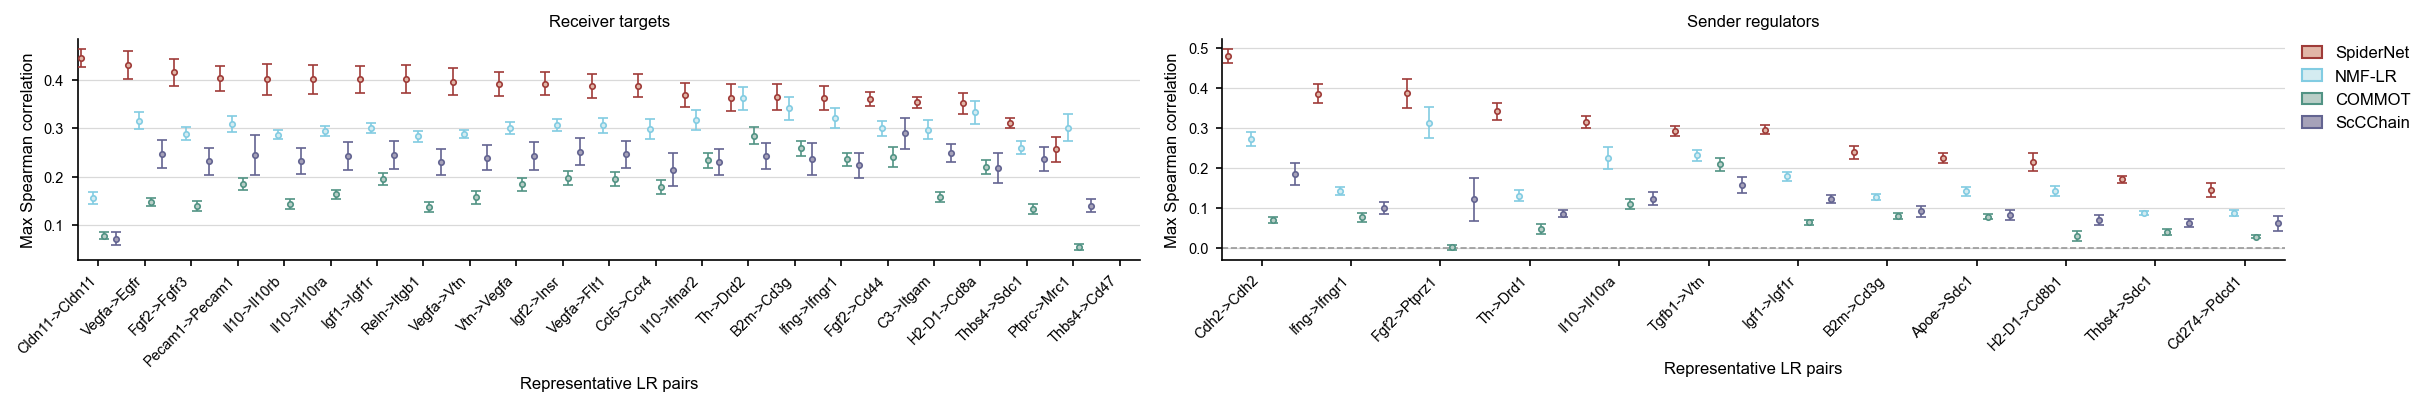

saved: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark1_curated_gene_coupling_byLR.png
saved: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark1_curated_gene_coupling_byLR.pdf


In [16]:

def plot_benchmark1(long_df, method_order, out_prefix):
    set_plot_style()

    feature_types = ["Receiver targets", "Sender regulators"]

    rep_lr_orders = {}
    max_n_lr = 0
    for feature_type in feature_types:
        sub_ft = long_df[long_df["FeatureType"] == feature_type].copy()
        rep_lr_order = (
            sub_ft[sub_ft["Method"] == "SpiderNet"]
            .groupby("RepresentativeLR")["Correlation"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
        rep_lr_orders[feature_type] = rep_lr_order
        max_n_lr = max(max_n_lr, len(rep_lr_order))

    fig_w = max(8.5, 1.4 + 0.42 * sum(len(v) for v in rep_lr_orders.values()))
    fig, axes = plt.subplots(1, 2, figsize=(fig_w, 2.6), constrained_layout=True)

    for ax, feature_type in zip(axes, feature_types):
        sub_ft = long_df[long_df["FeatureType"] == feature_type].copy()
        rep_lr_order = rep_lr_orders[feature_type]

        n_methods = len(method_order)
        feature_spacing = 1.10
        base_positions = np.arange(len(rep_lr_order)) * feature_spacing + 1
        group_width = 0.82
        offsets = np.linspace(-group_width / 2, group_width / 2, n_methods)

        all_lowers = []
        all_uppers = []

        for offset, method in zip(offsets, method_order):
            means = []
            lows = []
            highs = []

            for rep_lr in rep_lr_order:
                vals = sub_ft[
                    (sub_ft["RepresentativeLR"] == rep_lr) &
                    (sub_ft["Method"] == method)
                ]["Correlation"].dropna().to_numpy()

                mean_v, ci_low, ci_high, _ = mean_ci95(vals)
                means.append(mean_v)
                lows.append(ci_low)
                highs.append(ci_high)

            means = np.asarray(means, dtype=float)
            lows = np.asarray(lows, dtype=float)
            highs = np.asarray(highs, dtype=float)
            yerr = np.vstack([means - lows, highs - means])

            ax.errorbar(
                base_positions + offset,
                means,
                yerr=yerr,
                fmt="o",
                linestyle="none",
                color=METHOD_COLORS[method]["edge"],
                ecolor=METHOD_COLORS[method]["edge"],
                markersize=2.6,
                capsize=2.2,
                capthick=0.8,
                elinewidth=0.8,
                markerfacecolor=METHOD_COLORS[method]["fill"],
                markeredgecolor=METHOD_COLORS[method]["edge"],
                markeredgewidth=0.8,
                zorder=3,
            )

            all_lowers.append(lows)
            all_uppers.append(highs)

        ax.set_title(feature_type)
        ax.set_xticks(base_positions)
        ax.set_xticklabels(rep_lr_order, rotation=45, ha="right")
        ax.set_xlabel("Representative LR pairs")
        ax.set_ylabel("Max Spearman correlation")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", direction="out")
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, which="major", linestyle="-", linewidth=0.6, color="0.85")
        ax.xaxis.grid(False)
        ax.axhline(0, color="0.6", linestyle="--", linewidth=0.8, zorder=1)

        if len(rep_lr_order) > 0:
            left_margin = group_width / 2 + 0.08
            right_margin = group_width / 2 + 0.08
            ax.set_xlim(base_positions[0] - left_margin, base_positions[-1] + right_margin)

        all_lowers = np.concatenate(all_lowers) if len(all_lowers) > 0 else np.array([])
        all_uppers = np.concatenate(all_uppers) if len(all_uppers) > 0 else np.array([])
        valid_lower = all_lowers[np.isfinite(all_lowers)]
        valid_upper = all_uppers[np.isfinite(all_uppers)]

        if valid_lower.size > 0 and valid_upper.size > 0:
            ymin = float(np.min(valid_lower))
            ymax = float(np.max(valid_upper))
        else:
            ymin, ymax = -1.0, 1.0

        pad = 0.05 * (ymax - ymin) if (ymax - ymin) > 0 else 0.05
        ax.set_ylim(ymin - pad, ymax + pad)

    handles = [
        mpatches.Patch(
            facecolor=METHOD_COLORS[m]["fill"],
            edgecolor=METHOD_COLORS[m]["edge"],
            label=m,
        )
        for m in method_order
    ]

    axes[-1].legend(
        handles=handles,
        frameon=False,
        bbox_to_anchor=(1.01, 1.0),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=8,
        handlelength=1.2,
    )

    out_png = out_prefix + ".png"
    out_pdf = out_prefix + ".pdf"
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    return out_png, out_pdf


benchmark1_png, benchmark1_pdf = plot_benchmark1(
    benchmark1_long_df,
    benchmark1_method_order,
    os.path.join(benchmark_outdir, "Benchmark1_curated_gene_coupling_byLR"),
)

print("saved:", benchmark1_png)
print("saved:", benchmark1_pdf)

# Benchmark 2. Within-cell-type cell-cell similarity benchmark

This benchmark asks whether communication-derived cell representations preserve biologically meaningful relationships between cells of the same type.

For each slice and cell type:
1. Aggregate each method's edge-level outputs into **cell-level sender and receiver features**.
2. Compute a **cell-cell similarity matrix** from expression profiles and, separately, from each method's communication representation.
3. Compare the upper triangles of the two similarity matrices using **Spearman correlation**.

Higher correlation indicates that the communication representation better preserves expression-derived structure within that cell type.


In [17]:
# Build cell-level features for each method by aggregating edge-level communication features
cellclass_unique = np.unique(adata_all.obs[cfg["cellclass_name"]]).tolist()

method_cell_features = {
    "SpiderNet": [],
    "NMF-LR": [],
    "COMMOT": [],
    "ScCChain": [],
}
if cfg["include_spacia"]:
    method_cell_features["Spacia"] = []

for slice_index in range(len(adata_list)):
    print(f"Benchmark 2 feature prep | slice {slice_index + 1}/{len(adata_list)}")
    edge_index_cur = SpiderNet_data_pyg_list[slice_index]["edge_index"]
    num_cell_cur = SpiderNet_data_pyg_list[slice_index].x.shape[0]

    method_edge_features = {
        "SpiderNet": np.asarray(Factor_envir_list[slice_index], dtype=float),
        "NMF-LR": np.asarray(Factor_LR_list[slice_index], dtype=float),
        "COMMOT": np.asarray(COMMOT_score_list[slice_index], dtype=float),
        "ScCChain": np.asarray(ScCChain_CPscore_list[slice_index], dtype=float),
    }
    if cfg["include_spacia"]:
        method_edge_features["Spacia"] = np.asarray(Spacia_CP_list[slice_index], dtype=float)

    for method_name, edge_features in method_edge_features.items():
        agg = aggregate_sender_receiver(edge_features, edge_index_cur, num_cell_cur, device)
        method_cell_features[method_name].append(agg["combined"])

print("Prepared methods:", list(method_cell_features.keys()))


Benchmark 2 feature prep | slice 1/10
Benchmark 2 feature prep | slice 2/10
Benchmark 2 feature prep | slice 3/10
Benchmark 2 feature prep | slice 4/10
Benchmark 2 feature prep | slice 5/10
Benchmark 2 feature prep | slice 6/10
Benchmark 2 feature prep | slice 7/10
Benchmark 2 feature prep | slice 8/10
Benchmark 2 feature prep | slice 9/10
Benchmark 2 feature prep | slice 10/10
Prepared methods: ['SpiderNet', 'NMF-LR', 'COMMOT', 'ScCChain']


In [18]:
def upper_triangular_values(mat):
    return mat[np.triu_indices_from(mat, k=1)]


def compute_similarity_preservation_table(
    adata_list,
    method_cell_features,
    cellclass_name,
    min_cells_per_celltype=30,
):
    records = []

    for slice_index in range(len(adata_list)):
        adata_sub = adata_list[slice_index]
        X_expr = to_dense_2d(adata_sub.X)

        for celltype_cur in np.unique(adata_sub.obs[cellclass_name]).tolist():
            celltype_mask = (adata_sub.obs[cellclass_name] == celltype_cur).values
            n_cells = int(np.sum(celltype_mask))

            if n_cells < min_cells_per_celltype:
                continue

            expr_block = X_expr[celltype_mask]
            expr_sim_matrix = np.corrcoef(expr_block)
            expr_sim_matrix = np.nan_to_num(expr_sim_matrix, nan=0.0)
            expr_sim_values = upper_triangular_values(expr_sim_matrix)

            row = {
                "Slice": f"Slice_{slice_index + 1}",
                "CellType": celltype_cur,
                "n_cells": n_cells,
            }

            for method_name, feature_list in method_cell_features.items():
                feat_block = np.asarray(feature_list[slice_index][celltype_mask, :], dtype=float)
                feat_block = np.nan_to_num(feat_block, nan=0.0)

                feat_sim_matrix = np.corrcoef(feat_block)
                feat_sim_matrix = np.nan_to_num(feat_sim_matrix, nan=0.0)
                feat_sim_values = upper_triangular_values(feat_sim_matrix)

                corr_val, _ = spearmanr(expr_sim_values, feat_sim_values)
                row[method_name] = corr_val

            records.append(row)

    return pd.DataFrame(records)


benchmark2_corr_df = compute_similarity_preservation_table(
    adata_list=adata_list,
    method_cell_features=method_cell_features,
    cellclass_name=cfg["cellclass_name"],
    min_cells_per_celltype=MIN_CELLS_PER_CELLTYPE,
)

benchmark2_corr_df.to_csv(os.path.join(benchmark_outdir, "Benchmark2_cell_similarity_raw.csv"), index=False)
benchmark2_corr_df.head()


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Slice,CellType,n_cells,SpiderNet,NMF-LR,COMMOT,ScCChain
0,Slice_1,Astrocyte,6713,0.505772,0.419851,-0.011870,0.044806
1,Slice_1,B cell,95,0.488800,0.369944,0.006782,0.076329
2,Slice_1,Endothelial,5625,0.358805,0.251648,0.069975,0.072294
3,Slice_1,Ependymal,449,0.423174,0.311639,-0.023753,0.130621
4,Slice_1,Macrophage,402,0.452883,0.427423,0.081919,0.258485


In [19]:
def make_benchmark2_long_and_stats(corr_df):
    method_order = [m for m in ["SpiderNet", "NMF-LR", "COMMOT", "ScCChain", "Spacia"] if m in corr_df.columns]

    long_df = corr_df.melt(
        id_vars=["Slice", "CellType", "n_cells"],
        value_vars=method_order,
        var_name="Method",
        value_name="Correlation",
    )
    long_df["Correlation"] = pd.to_numeric(long_df["Correlation"], errors="coerce")

    # Order cell types by the median SpiderNet score for display
    spider_median = (
        long_df[long_df["Method"] == "SpiderNet"]
        .groupby("CellType")["Correlation"]
        .median()
        .sort_values(ascending=False)
    )
    cell_order = spider_median.index.tolist()
    for ct in sorted(long_df["CellType"].unique()):
        if ct not in cell_order:
            cell_order.append(ct)

    stats_records = []
    for celltype in cell_order:
        sub = long_df[long_df["CellType"] == celltype]
        spider = sub[sub["Method"] == "SpiderNet"]["Correlation"].to_numpy()

        for method in method_order:
            vals = sub[sub["Method"] == method]["Correlation"].to_numpy()
            s = summarize_values(vals)
            p_vs_spider = np.nan if method == "SpiderNet" else one_sided_mw_greater(spider, vals)
            stats_records.append({
                "CellType": celltype,
                "Method": method,
                "n": s["n"],
                "mean": s["mean"],
                "median": s["median"],
                "sd": s["sd"],
                "p_SpiderNet_greater": p_vs_spider,
            })

    stats_df = pd.DataFrame(stats_records)
    return long_df, stats_df, method_order, cell_order


benchmark2_long_df, benchmark2_stats_df, benchmark2_method_order, benchmark2_cell_order = make_benchmark2_long_and_stats(
    benchmark2_corr_df
)

benchmark2_long_df.to_csv(os.path.join(benchmark_outdir, "Benchmark2_long.csv"), index=False)
benchmark2_stats_df.to_csv(os.path.join(benchmark_outdir, "Benchmark2_summary_stats.csv"), index=False)

benchmark2_stats_df.head()


,CellType,Method,n,mean,median,sd,p_SpiderNet_greater
0,OPC,SpiderNet,10,0.591972,0.589225,0.019381,NaN
1,OPC,NMF-LR,10,0.480062,0.485362,0.030620,0.000091
2,OPC,COMMOT,10,-0.037651,-0.038184,0.011905,0.000091
3,OPC,ScCChain,10,0.038627,0.028838,0.035526,0.000091
4,Neutrophil,SpiderNet,7,0.554289,0.576406,0.066713,NaN


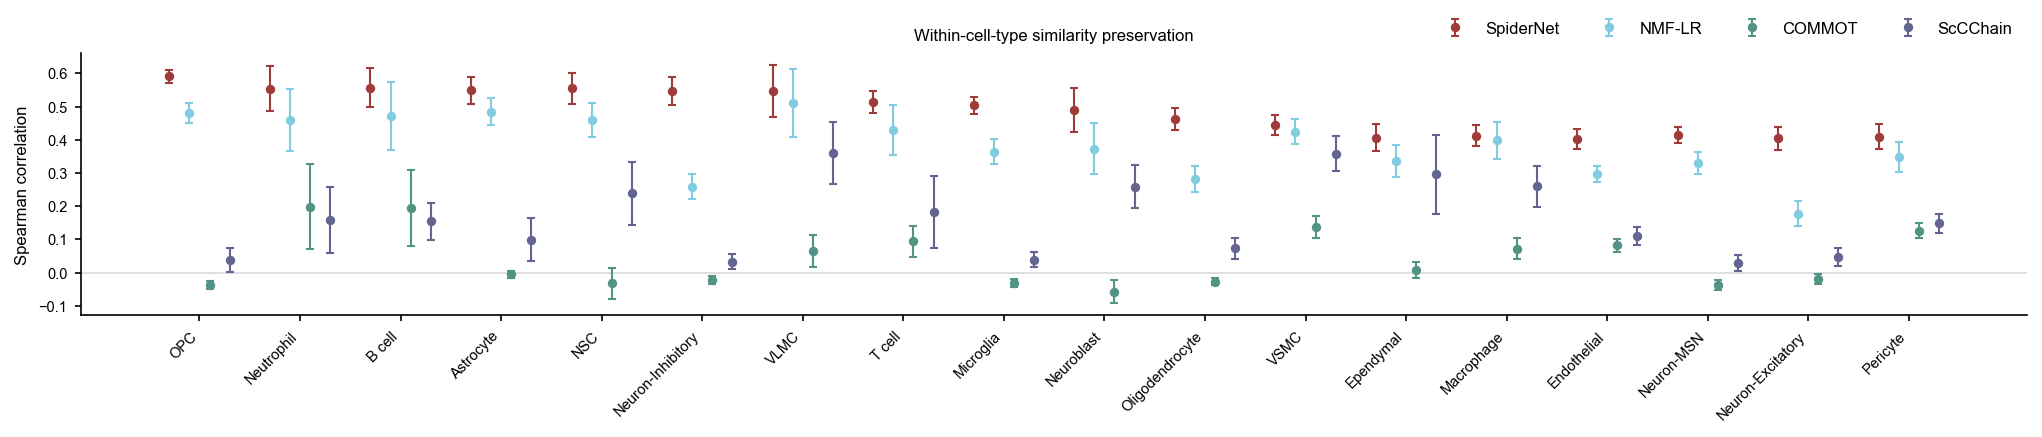

saved: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark2_within_celltype_similarity.png
saved: D:/SpiderNet/Results/AgingBrain/V1/SpiderNet_Result_dim30/Unified_CCC_benchmarking\Benchmark2_within_celltype_similarity.pdf


In [20]:
def plot_benchmark2(long_df, method_order, cell_order, out_prefix):
    set_plot_style()

    summary_records = []
    for celltype in cell_order:
        for method in method_order:
            vals = long_df[
                (long_df["CellType"] == celltype) &
                (long_df["Method"] == method)
            ]["Correlation"].dropna().to_numpy()

            if vals.size == 0:
                summary_records.append({
                    "CellType": celltype,
                    "Method": method,
                    "mean": np.nan,
                    "sd": np.nan,
                    "n": 0,
                })
            elif vals.size == 1:
                summary_records.append({
                    "CellType": celltype,
                    "Method": method,
                    "mean": float(vals[0]),
                    "sd": np.nan,
                    "n": 1,
                })
            else:
                summary_records.append({
                    "CellType": celltype,
                    "Method": method,
                    "mean": float(np.mean(vals)),
                    "sd": float(np.std(vals, ddof=1)),
                    "n": int(vals.size),
                })

    summary_df = pd.DataFrame(summary_records)
    summary_df.to_csv(out_prefix + "_plot_summary.csv", index=False)

    fig_width = max(7.0, 0.75 * len(cell_order))
    fig, ax = plt.subplots(figsize=(fig_width, 2.8), constrained_layout=True)

    base_positions = np.arange(len(cell_order))
    offsets = np.linspace(-0.30, 0.30, len(method_order))

    for offset, method in zip(offsets, method_order):
        sub = summary_df[summary_df["Method"] == method].set_index("CellType").reindex(cell_order)
        ax.errorbar(
            base_positions + offset,
            sub["mean"].values,
            yerr=sub["sd"].values,
            fmt="o",
            markersize=3.5,
            linewidth=1.0,
            capsize=2,
            color=METHOD_COLORS[method]["edge"],
            label=method,
        )

    ax.set_xticks(base_positions)
    ax.set_xticklabels(cell_order, rotation=45, ha="right")
    ax.set_ylabel("Spearman correlation")
    ax.set_title("Within-cell-type similarity preservation")
    ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, ncol=min(len(method_order), 5), bbox_to_anchor=(1.0, 1.18), loc="upper right")

    out_png = out_prefix + ".png"
    out_pdf = out_prefix + ".pdf"
    fig.savefig(out_png, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    return summary_df, out_png, out_pdf


benchmark2_plot_summary_df, benchmark2_png, benchmark2_pdf = plot_benchmark2(
    benchmark2_long_df,
    benchmark2_method_order,
    benchmark2_cell_order,
    os.path.join(benchmark_outdir, "Benchmark2_within_celltype_similarity"),
)

print("saved:", benchmark2_png)
print("saved:", benchmark2_pdf)
